In [2]:
# Bibliotheken importieren
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Visualisierungsstile konfigurieren
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Bereinigten Datensatz einlesen
df = pd.read_csv('AmesHousing_cleaned.csv')


In [4]:
# Dimensionen
print(df.shape)

# Erste Zeilen
print(df.head())

# Informationen zu Spalten
print(df.info())

# Statistische Übersicht
print(df.describe())

(2929, 51)
  MS Zoning Street Alley Lot Shape Land Contour Utilities Lot Config  \
0        RL   Pave   NaN       IR1          Lvl    AllPub     Corner   
1        RH   Pave   NaN       Reg          Lvl    AllPub     Inside   
2        RL   Pave   NaN       IR1          Lvl    AllPub     Corner   
3        RL   Pave   NaN       Reg          Lvl    AllPub     Corner   
4        RL   Pave   NaN       IR1          Lvl    AllPub     Inside   

  Land Slope Neighborhood Condition 1  ... Garage Finish Garage Cars  \
0        Gtl        NAmes        Norm  ...           Fin         2.0   
1        Gtl        NAmes       Feedr  ...           Unf         1.0   
2        Gtl        NAmes        Norm  ...           Unf         1.0   
3        Gtl        NAmes        Norm  ...           Fin         2.0   
4        Gtl      Gilbert        Norm  ...           Fin         2.0   

   Garage Area  Garage Qual  Garage Cond Paved Drive  Fence Sale Type  \
0        528.0           TA           TA          

In [5]:
# numerische Spalten identifizieren
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(f"Numerische Spalten: {list(numeric_cols)}")

Numerische Spalten: ['Overall Qual', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'Total Bsmt SF', '1st Flr SF', 'Gr Liv Area', 'Full Bath', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'SalePrice']


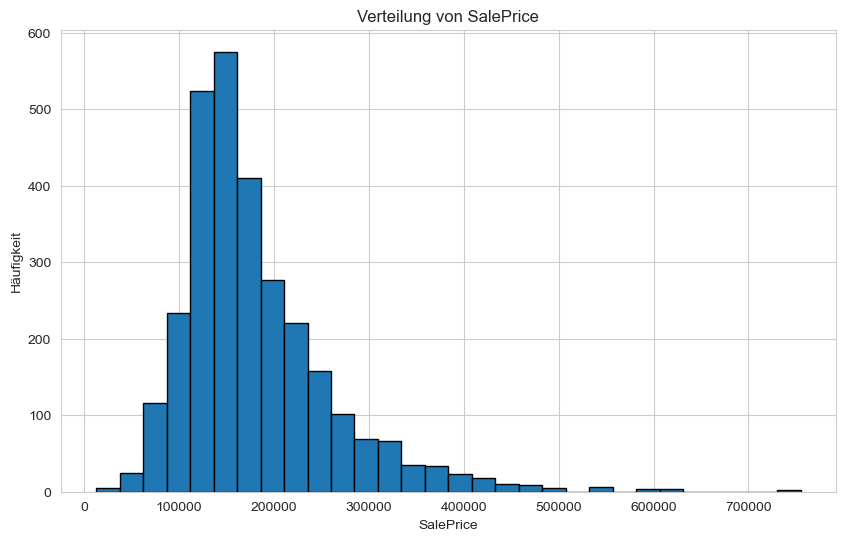

In [6]:
# Histogramm für SalePrice
plt.figure(figsize=(10, 6))
plt.hist(df['SalePrice'], bins=30, edgecolor='black')
plt.title('Verteilung von SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Häufigkeit')
plt.show()

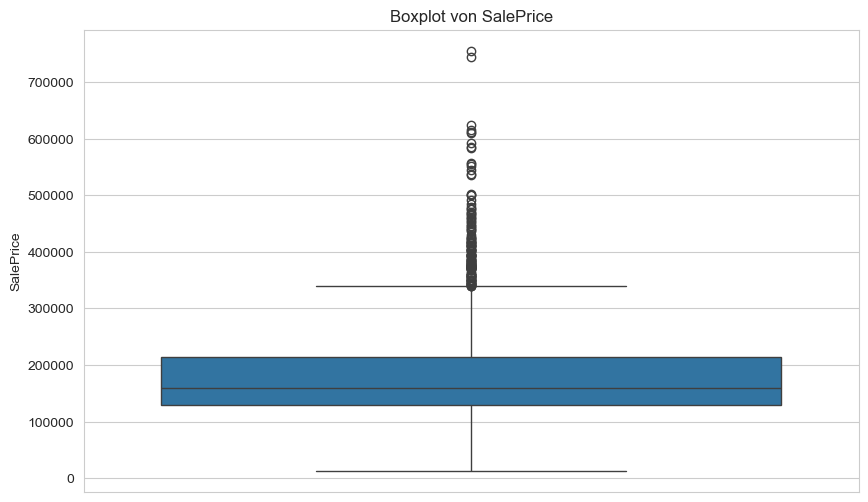

In [7]:
# Boxplot für SalePrice
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['SalePrice'])
plt.title('Boxplot von SalePrice')
plt.show()

In [8]:
# kategoriale Spalten identifizieren
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(f"Kategoriale Spalten: {list(categorical_cols)}")

Kategoriale Spalten: ['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Bldg Type', 'House Style', 'Roof Style', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating QC', 'Central Air', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Fence', 'Sale Type', 'Sale Condition']


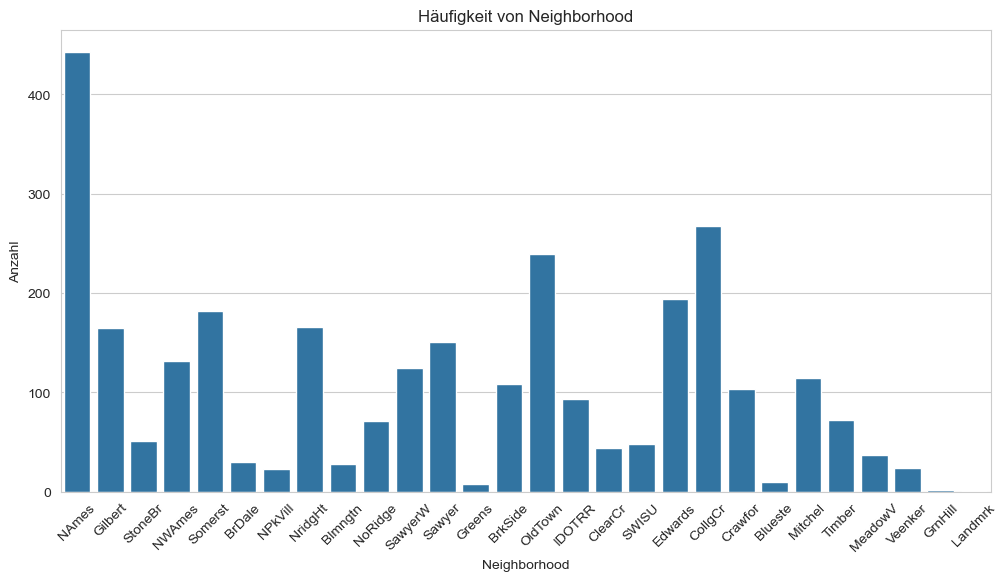

In [9]:
# Count Plot für Neighborhood
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Neighborhood')
plt.title('Häufigkeit von Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Anzahl')
plt.xticks(rotation=45)
plt.show()

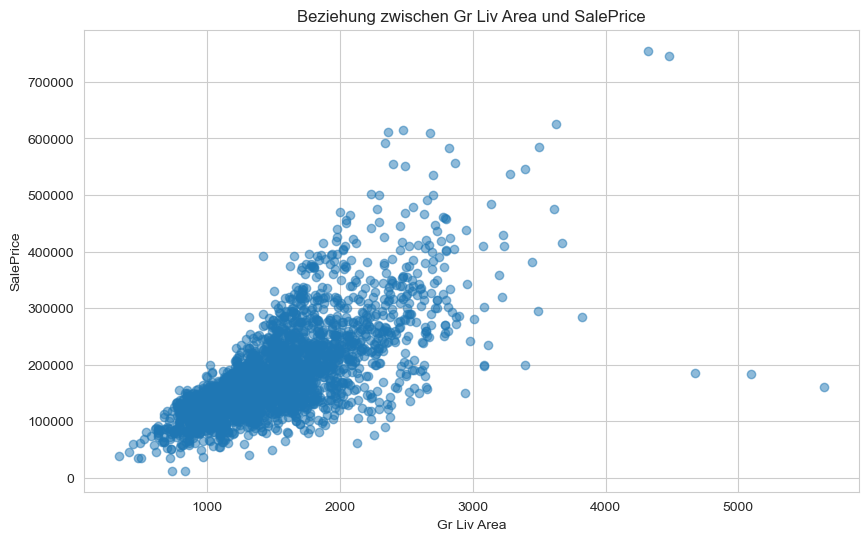

In [10]:
# Scatter Plot: Gr Liv Area vs. SalePrice
plt.figure(figsize=(10, 6))
plt.scatter(df['Gr Liv Area'], df['SalePrice'], alpha=0.5)
plt.title('Beziehung zwischen Gr Liv Area und SalePrice')
plt.xlabel('Gr Liv Area')
plt.ylabel('SalePrice')
plt.show()

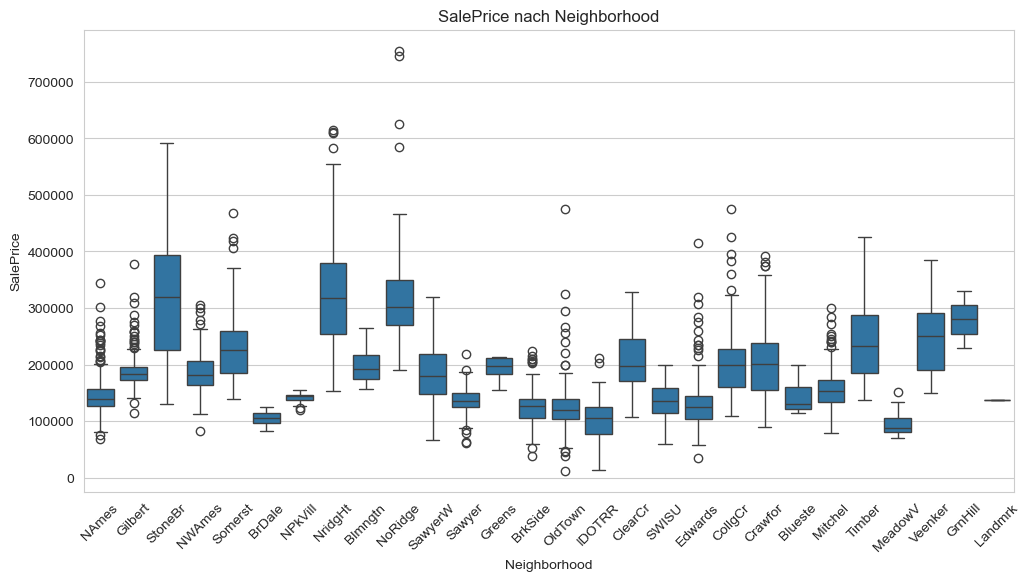

In [11]:
# Boxplot: SalePrice nach Neighborhood
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Neighborhood', y='SalePrice')
plt.title('SalePrice nach Neighborhood')
plt.xticks(rotation=45)
plt.show()

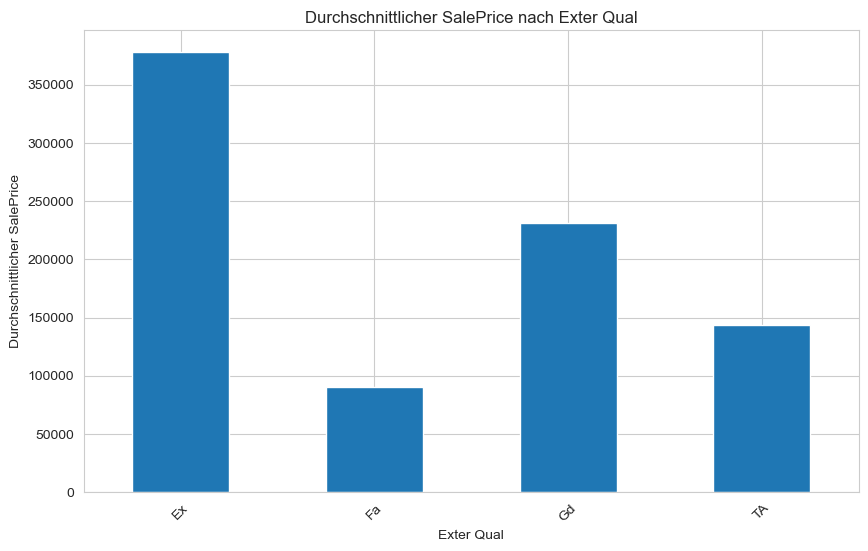

In [12]:
# Grouped Bar Chart: durchschnittlicher SalePrice nach Exter Qual
grouped_data = df.groupby('Exter Qual')['SalePrice'].mean()

plt.figure(figsize=(10, 6))
grouped_data.plot(kind='bar')
plt.title('Durchschnittlicher SalePrice nach Exter Qual')
plt.xlabel('Exter Qual')
plt.ylabel('Durchschnittlicher SalePrice')
plt.xticks(rotation=45)
plt.show()

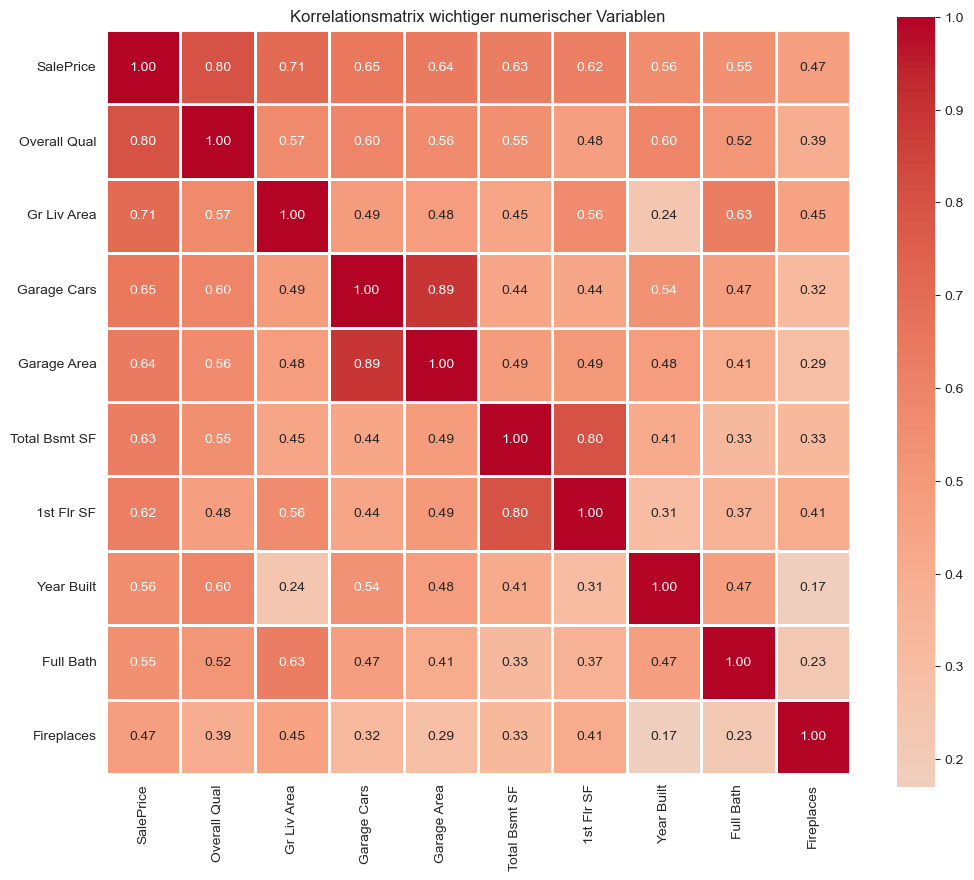

In [13]:
# wichtige numerische Spalten auswählen
selected_numeric_cols = [
    'SalePrice',
    'Overall Qual',
    'Gr Liv Area',
    'Garage Cars',
    'Garage Area',
    'Total Bsmt SF',
    '1st Flr SF',
    'Year Built',
    'Full Bath',
    'Fireplaces'
]

# Korrelationsmatrix berechnen
correlation_matrix = df[selected_numeric_cols].corr()

# Heatmap der Korrelationen
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.2f')
plt.title('Korrelationsmatrix wichtiger numerischer Variablen')
plt.show()

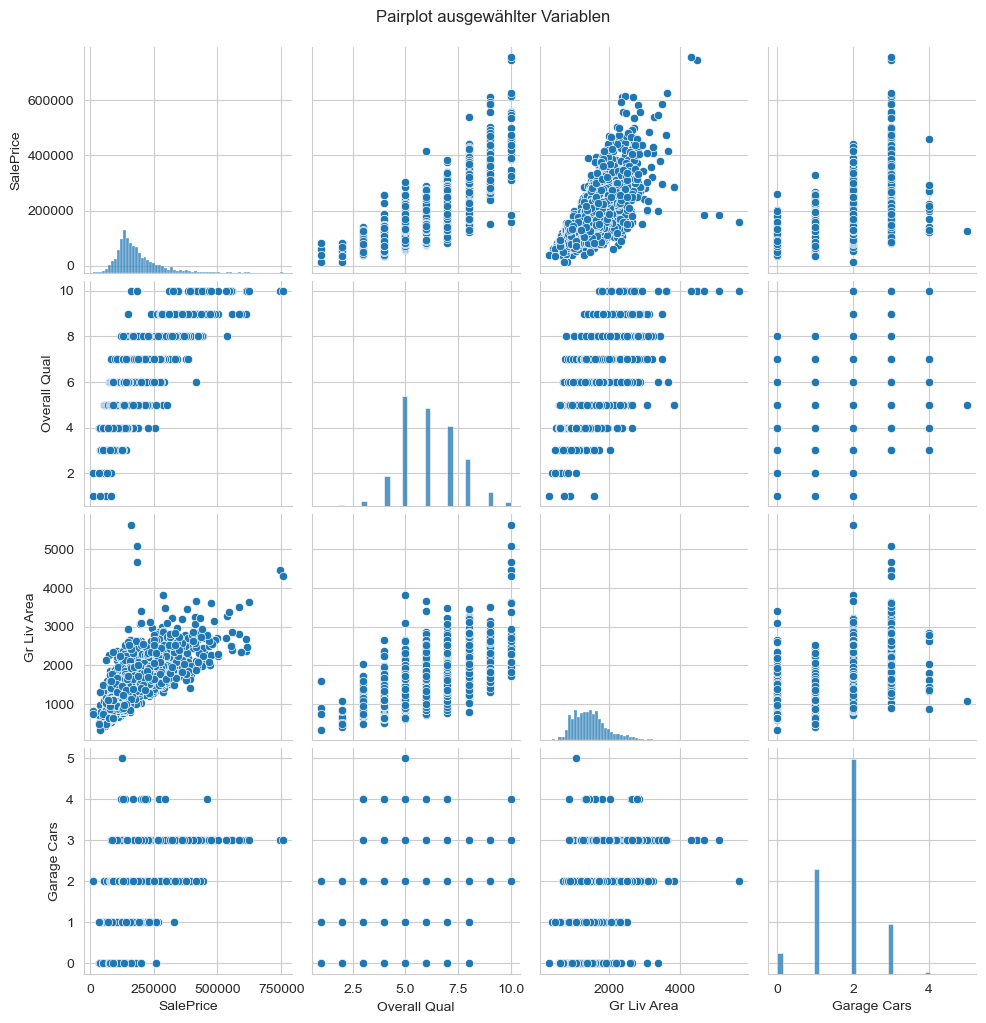

In [14]:
# Pairplot für ausgewählte Variablen
selected_cols = ['SalePrice', 'Overall Qual', 'Gr Liv Area', 'Garage Cars']

sns.pairplot(df[selected_cols])
plt.suptitle('Pairplot ausgewählter Variablen', y=1.02)
plt.show()

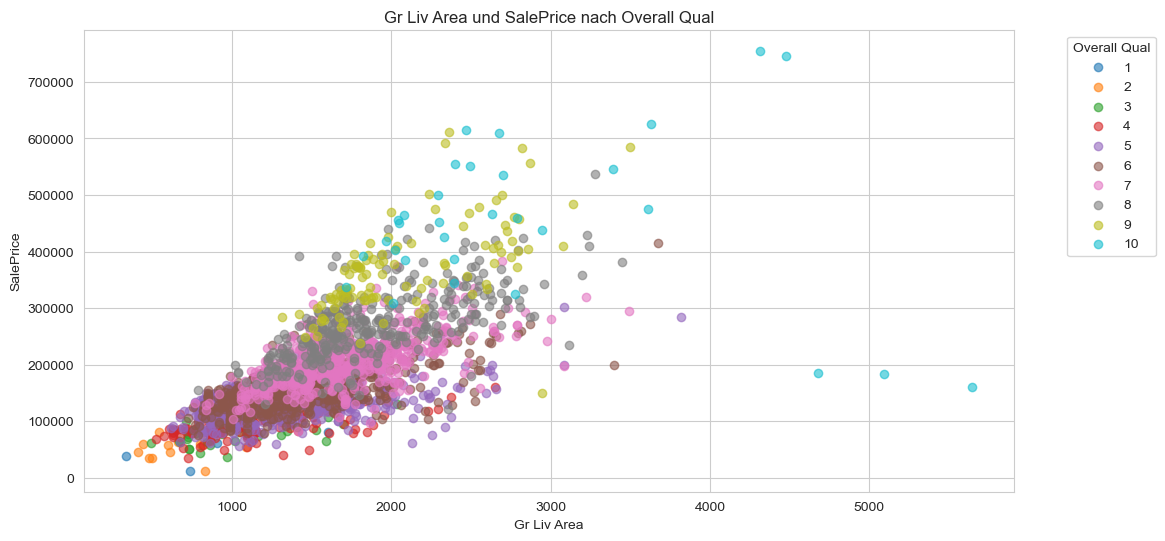

In [15]:
# Scatter Plot mit Farbkodierung nach Overall Qual
plt.figure(figsize=(12, 6))

for category in sorted(df['Overall Qual'].unique()):
    subset = df[df['Overall Qual'] == category]
    plt.scatter(subset['Gr Liv Area'], subset['SalePrice'], label=category, alpha=0.6)

plt.title('Gr Liv Area und SalePrice nach Overall Qual')
plt.xlabel('Gr Liv Area')
plt.ylabel('SalePrice')
plt.legend(title='Overall Qual', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

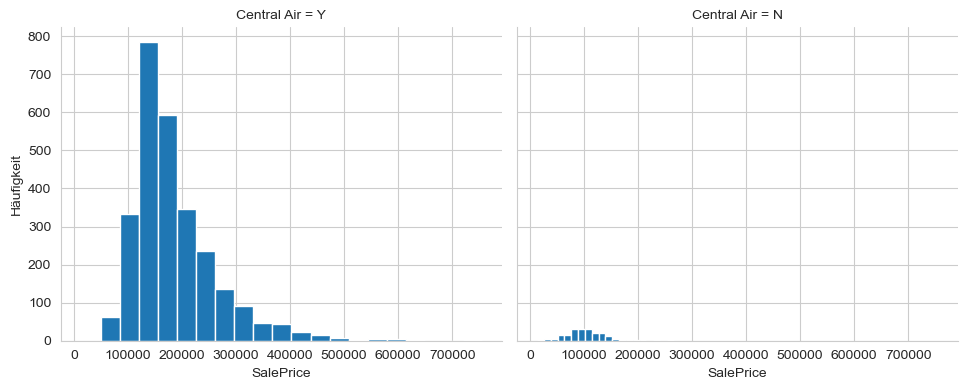

In [16]:
# FacetGrid: Verteilung von SalePrice nach Central Air
g = sns.FacetGrid(df, col='Central Air', height=4, aspect=1.2)
g.map(plt.hist, 'SalePrice', bins=20)
g.set_axis_labels('SalePrice', 'Häufigkeit')
g.set_titles(col_template='Central Air = {col_name}')
plt.show()

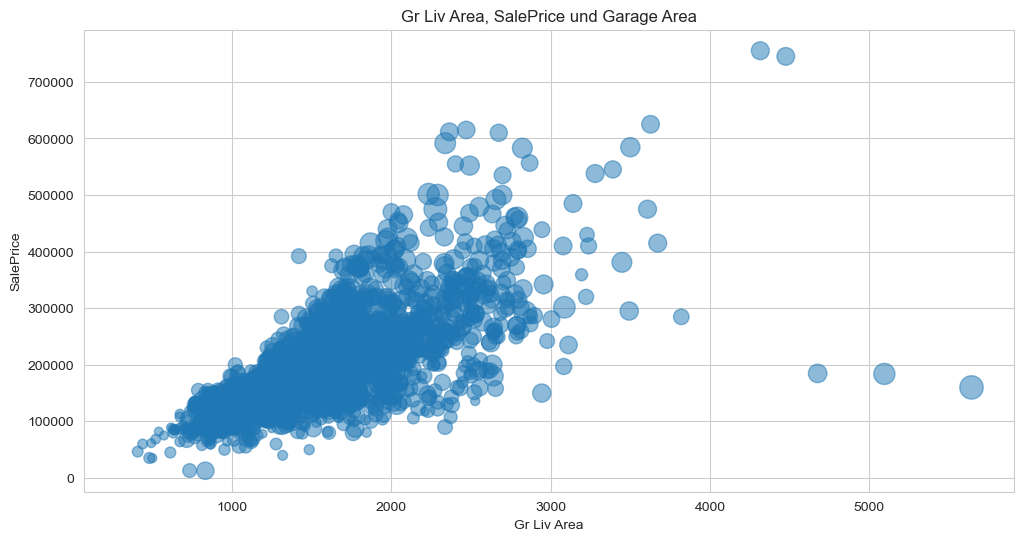

In [17]:
# Bubble Chart
plt.figure(figsize=(12, 6))
plt.scatter(
    df['Gr Liv Area'],
    df['SalePrice'],
    s=df['Garage Area'] / 5,
    alpha=0.5
)

plt.title('Gr Liv Area, SalePrice und Garage Area')
plt.xlabel('Gr Liv Area')
plt.ylabel('SalePrice')
plt.show()

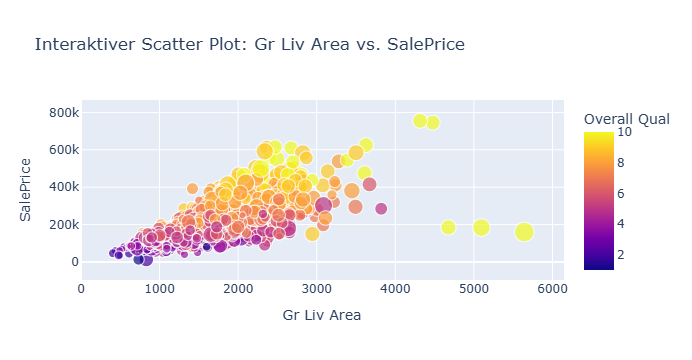

In [18]:
# Interaktiver Scatter Plot
fig = px.scatter(
    df,
    x='Gr Liv Area',
    y='SalePrice',
    color='Overall Qual',
    size='Garage Area',
    hover_data=['Neighborhood', 'Year Built', 'Garage Cars'],
    title='Interaktiver Scatter Plot: Gr Liv Area vs. SalePrice'
)

fig.show()

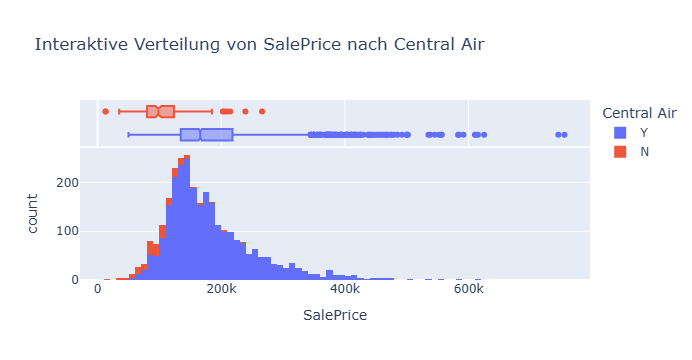

In [19]:
# Interaktives Histogramm
fig = px.histogram(
    df,
    x='SalePrice',
    color='Central Air',
    marginal='box',
    title='Interaktive Verteilung von SalePrice nach Central Air'
)

fig.show()

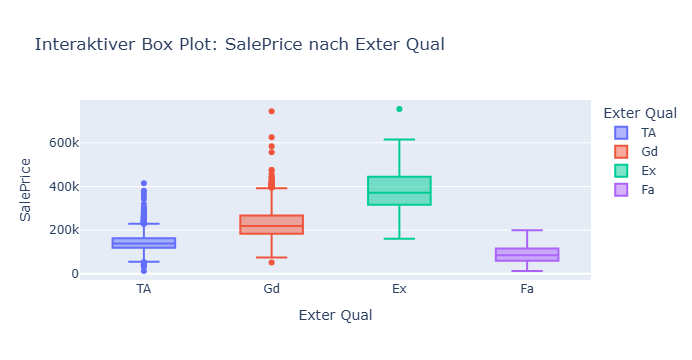

In [20]:
# Interaktiver Box Plot
fig = px.box(
    df,
    x='Exter Qual',
    y='SalePrice',
    color='Exter Qual',
    title='Interaktiver Box Plot: SalePrice nach Exter Qual'
)

fig.show()

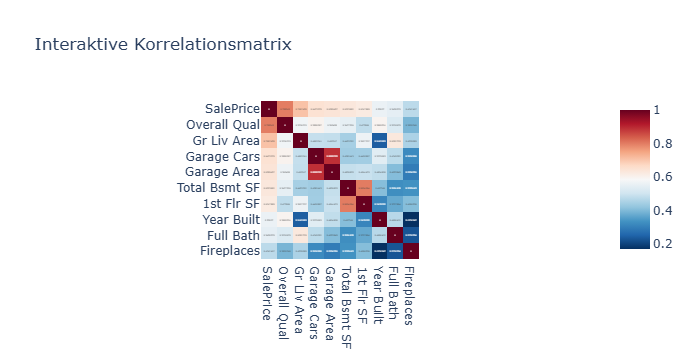

In [21]:
# Interaktive Korrelationsmatrix
fig = px.imshow(
    correlation_matrix,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    title='Interaktive Korrelationsmatrix'
)

fig.show()

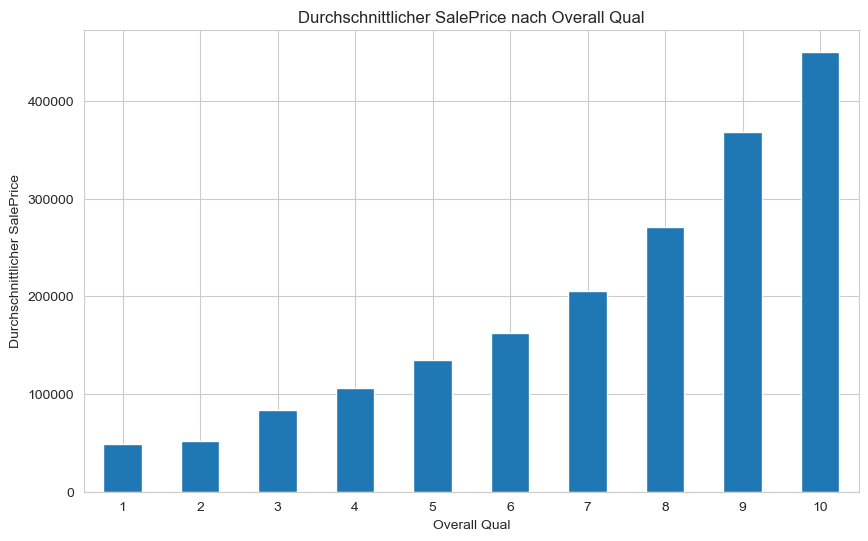

In [22]:
# Visualisierung 1: Durchschnittlicher SalePrice nach Overall Qual
avg_price_qual = df.groupby("Overall Qual")["SalePrice"].mean()

plt.figure(figsize=(10, 6))
avg_price_qual.plot(kind="bar")
plt.title("Durchschnittlicher SalePrice nach Overall Qual")
plt.xlabel("Overall Qual")
plt.ylabel("Durchschnittlicher SalePrice")
plt.xticks(rotation=0)
plt.show()

#Interpretation Visualisierung 1:
#Mit steigender Hausqualität (Overall Qual) steigt auch der 
#durchschnittliche Verkaufspreis deutlich. Die Hausqualität gehört damit 
#zu den wichtigsten Einflussfaktoren für SalePrice.

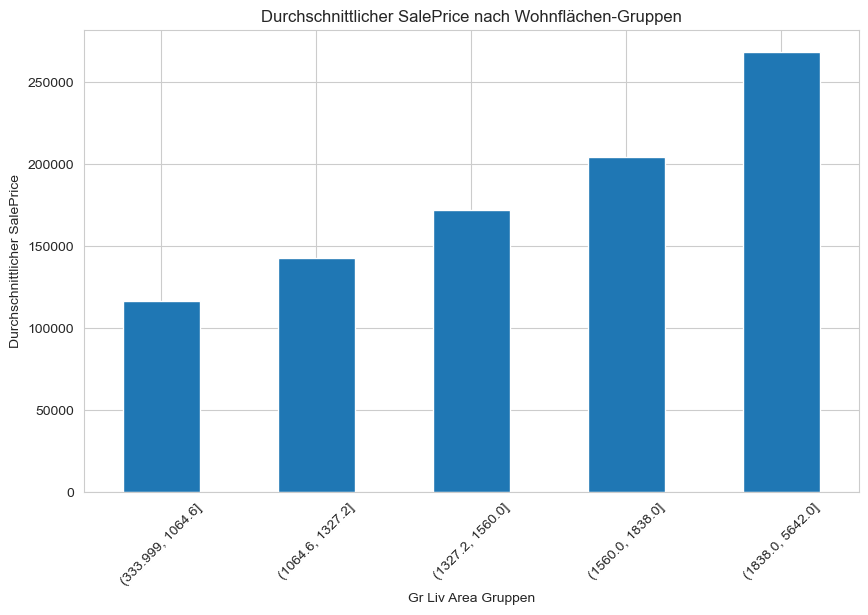

In [23]:
# Visualisierung 2: Gr Liv Area in Gruppen und durchschnittlicher SalePrice
df["Area_Group"] = pd.qcut(df["Gr Liv Area"], 5)

avg_price_area = df.groupby("Area_Group", observed=False)["SalePrice"].mean()

plt.figure(figsize=(10, 6))
avg_price_area.plot(kind="bar")
plt.title("Durchschnittlicher SalePrice nach Wohnflächen-Gruppen")
plt.xlabel("Gr Liv Area Gruppen")
plt.ylabel("Durchschnittlicher SalePrice")
plt.xticks(rotation=45)
plt.show()

#Interpretation Visualisierung 2:
#Auch die Wohnfläche (Gr Liv Area) zeigt einen klaren Zusammenhang mit SalePrice. 
#Häuser mit größerer Wohnfläche haben im Durchschnitt höhere Verkaufspreise.

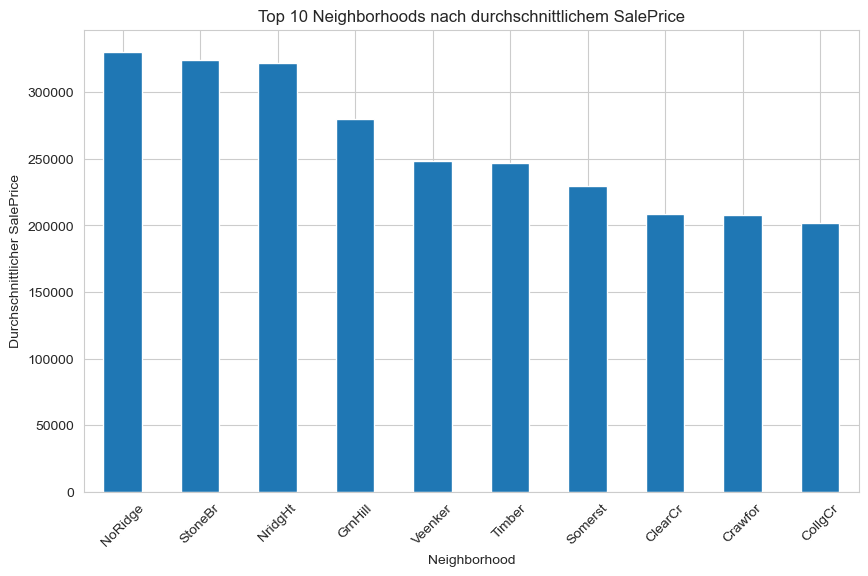

In [24]:
# Visualisierung 3: Top 10 Neighborhoods nach durchschnittlichem SalePrice
avg_price_neighborhood = df.groupby("Neighborhood")["SalePrice"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
avg_price_neighborhood.head(10).plot(kind="bar")
plt.title("Top 10 Neighborhoods nach durchschnittlichem SalePrice")
plt.xlabel("Neighborhood")
plt.ylabel("Durchschnittlicher SalePrice")
plt.xticks(rotation=45)
plt.show()

#Interpretation Visualisierung 3:
#Die Lage bzw. Neighborhood hat einen starken Einfluss auf den Verkaufspreis. 
#Zwischen den Stadtteilen gibt es deutliche Preisunterschiede, was zeigt, 
#dass die Lage eine wichtige Rolle für SalePrice spielt.

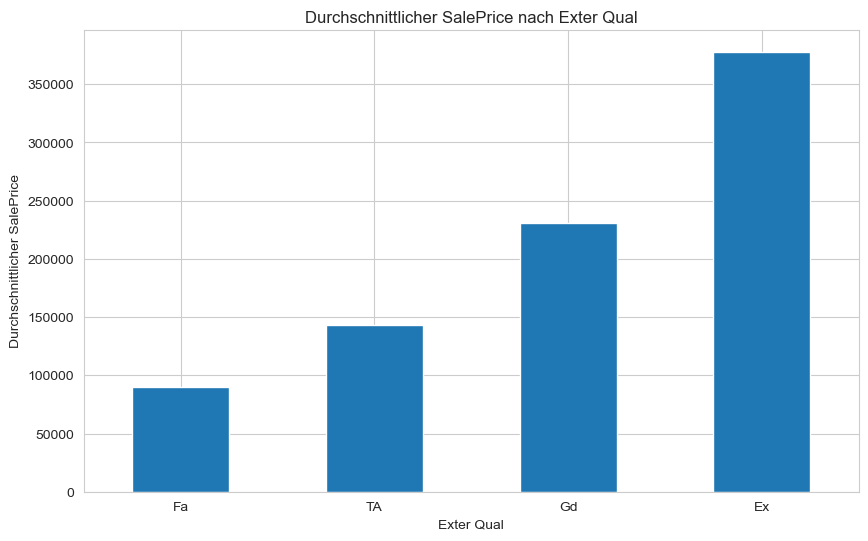

In [25]:
# Visualisierung 4: Durchschnittlicher SalePrice nach Exter Qual
avg_price_exter = df.groupby("Exter Qual")["SalePrice"].mean().sort_values()

plt.figure(figsize=(10, 6))
avg_price_exter.plot(kind="bar")
plt.title("Durchschnittlicher SalePrice nach Exter Qual")
plt.xlabel("Exter Qual")
plt.ylabel("Durchschnittlicher SalePrice")
plt.xticks(rotation=0)
plt.show()
#Zeigt, ob die Außenqualität den Preis beeinflusst.

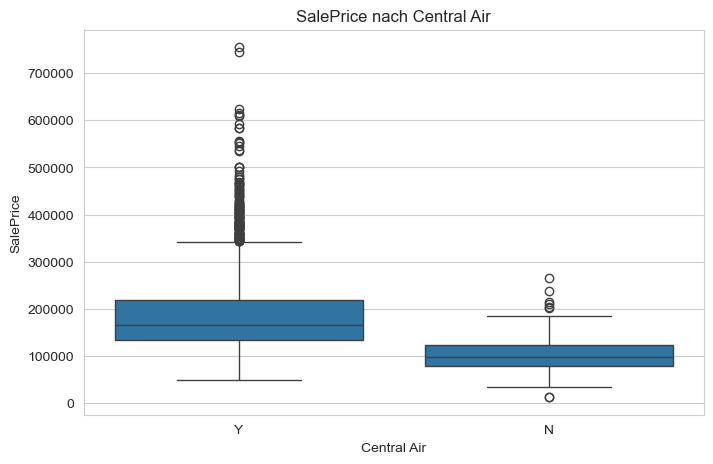

In [26]:
# Visualisierung 5: SalePrice nach Central Air
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Central Air", y="SalePrice")
plt.title("SalePrice nach Central Air")
plt.xlabel("Central Air")
plt.ylabel("SalePrice")
plt.show()
#Einfach und gut verständlich. Zeigt, ob Häuser mit Klimaanlage teurer sind.

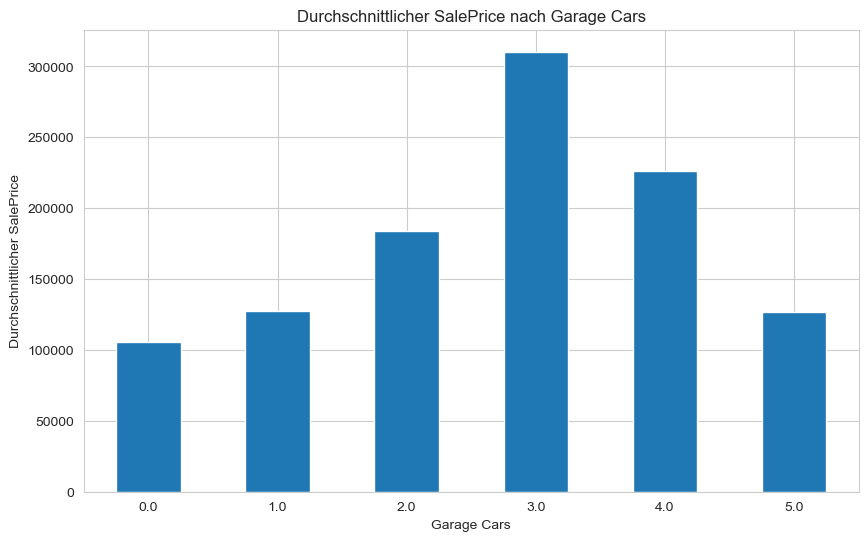

In [27]:
# Visualisierung 6: Durchschnittlicher SalePrice nach Garage Cars
avg_price_garage = df.groupby("Garage Cars")["SalePrice"].mean()

plt.figure(figsize=(10, 6))
avg_price_garage.plot(kind="bar")
plt.title("Durchschnittlicher SalePrice nach Garage Cars")
plt.xlabel("Garage Cars")
plt.ylabel("Durchschnittlicher SalePrice")
plt.xticks(rotation=0)
plt.show()
#Zeigt, ob die Garagengröße bzw. Zahl der Stellplätze mit dem Preis zusammenhängt.

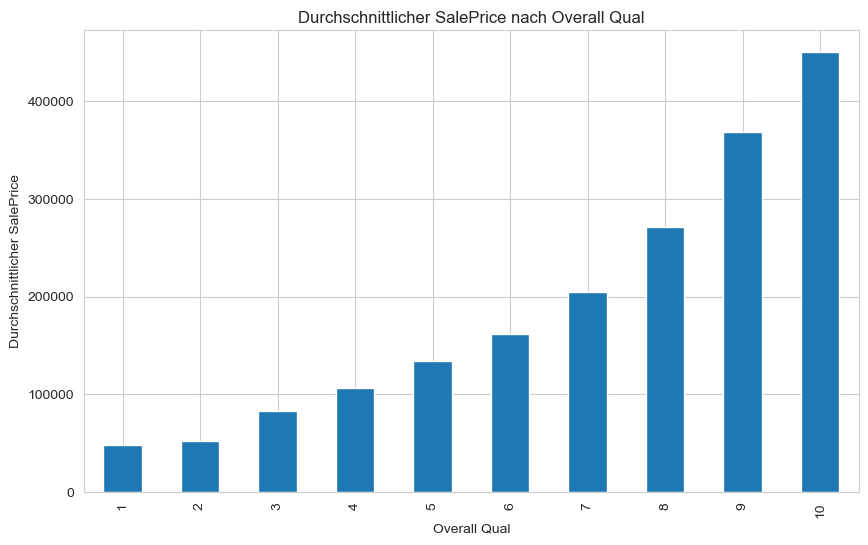

In [28]:
# Visualisierung 1 speichern
avg_price_qual = df.groupby("Overall Qual")["SalePrice"].mean()

plt.figure(figsize=(10, 6))
avg_price_qual.plot(kind="bar")
plt.title("Durchschnittlicher SalePrice nach Overall Qual")
plt.xlabel("Overall Qual")
plt.ylabel("Durchschnittlicher SalePrice")

plt.savefig("saleprice_overallqual.png", dpi=300, bbox_inches="tight")
plt.show()

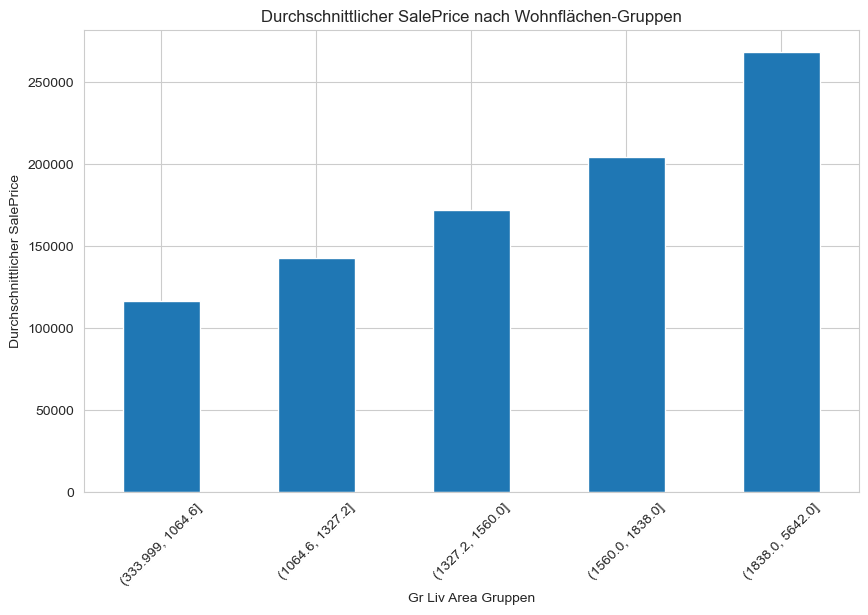

In [29]:
# Visualisierung 2 speichern
df["Area_Group"] = pd.qcut(df["Gr Liv Area"], 5)

avg_price_area = df.groupby("Area_Group", observed=False)["SalePrice"].mean()

plt.figure(figsize=(10, 6))
avg_price_area.plot(kind="bar")
plt.title("Durchschnittlicher SalePrice nach Wohnflächen-Gruppen")
plt.xlabel("Gr Liv Area Gruppen")
plt.ylabel("Durchschnittlicher SalePrice")
plt.xticks(rotation=45)

plt.savefig("saleprice_grlivarea.png", dpi=300, bbox_inches="tight")
plt.show()

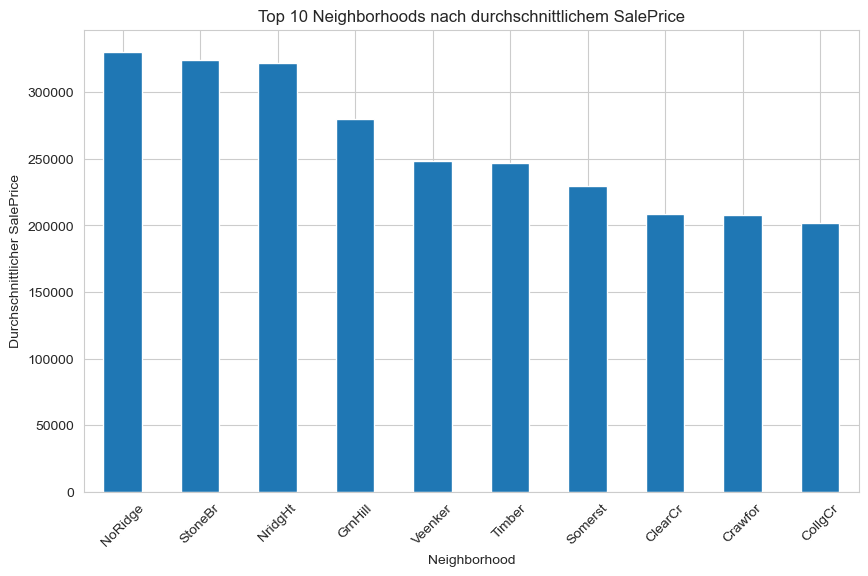

In [30]:
# Visualisierung 3 speichern
avg_price_neighborhood = df.groupby("Neighborhood")["SalePrice"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
avg_price_neighborhood.head(10).plot(kind="bar")
plt.title("Top 10 Neighborhoods nach durchschnittlichem SalePrice")
plt.xlabel("Neighborhood")
plt.ylabel("Durchschnittlicher SalePrice")
plt.xticks(rotation=45)

plt.savefig("saleprice_neighborhood.png", dpi=300, bbox_inches="tight")
plt.show()

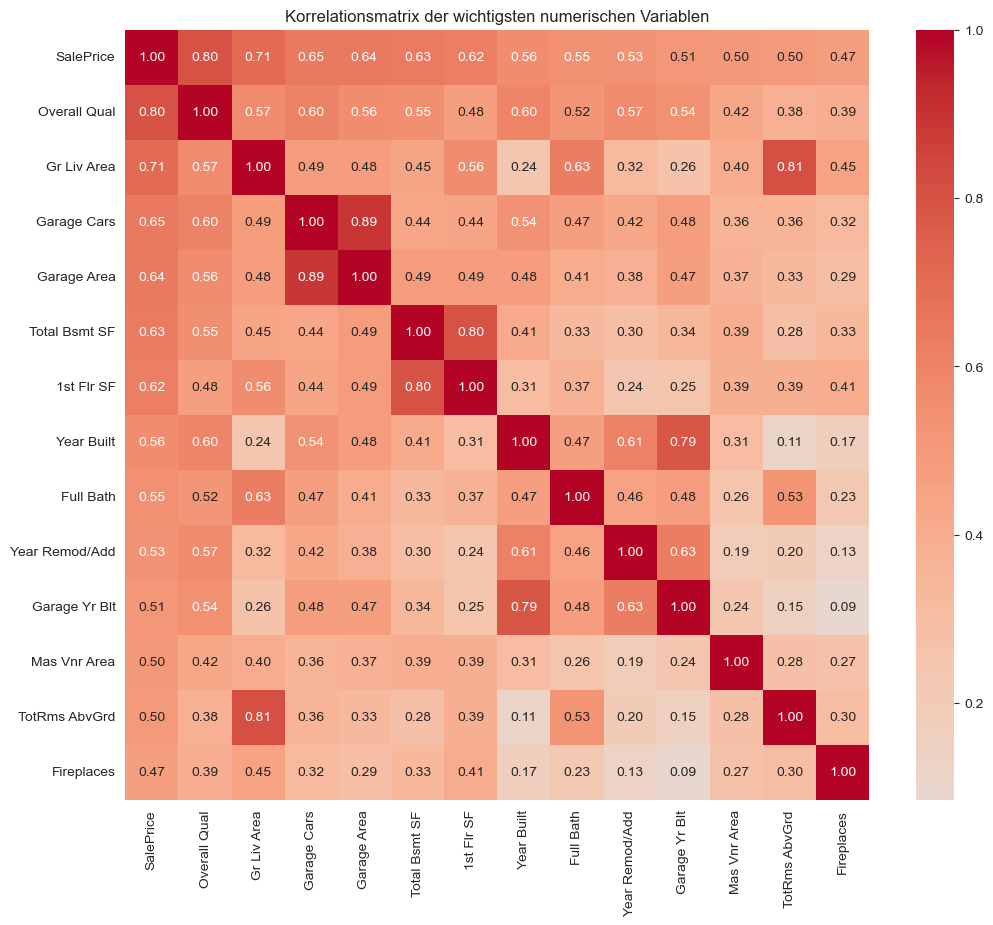

In [31]:
# Korrelations-Heatmap für die wichtigsten numerischen Spalten
top_num_cols = [
    'SalePrice',
    'Overall Qual',
    'Gr Liv Area',
    'Garage Cars',
    'Garage Area',
    'Total Bsmt SF',
    '1st Flr SF',
    'Year Built',
    'Full Bath',
    'Year Remod/Add',
    'Garage Yr Blt',
    'Mas Vnr Area',
    'TotRms AbvGrd',
    'Fireplaces'
]

corr_matrix = df[top_num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Korrelationsmatrix der wichtigsten numerischen Variablen')
plt.show()

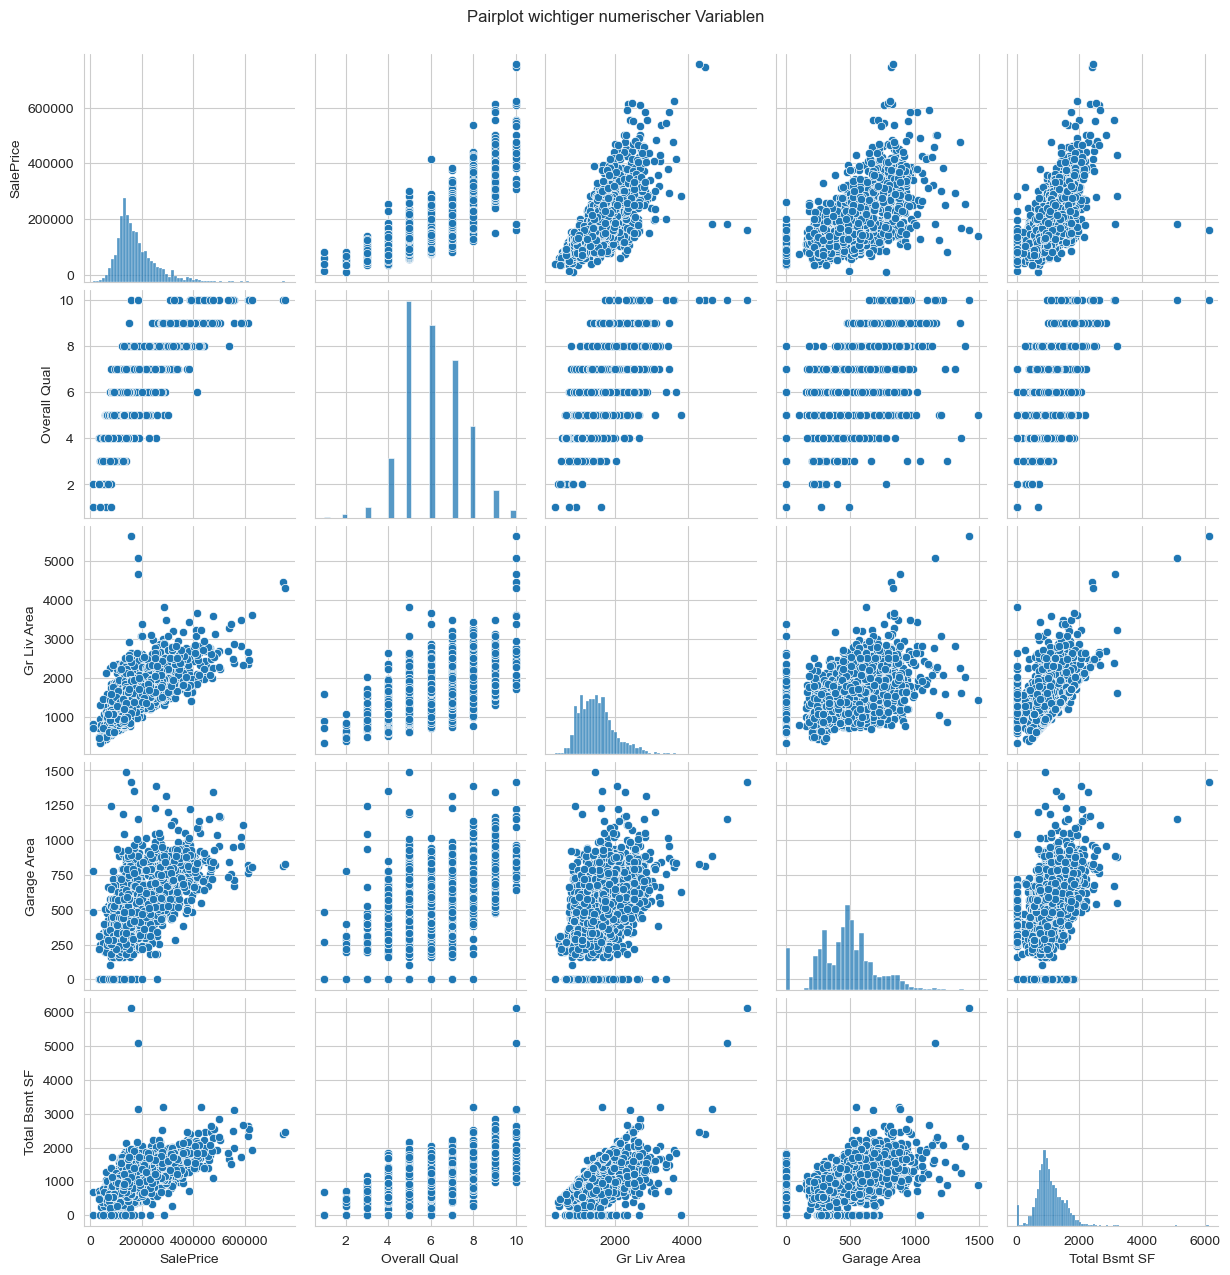

In [32]:
# Pairplot für ausgewählte Top-Variablen
pair_cols = ['SalePrice', 'Overall Qual', 'Gr Liv Area', 'Garage Area', 'Total Bsmt SF']

sns.pairplot(df[pair_cols])
plt.suptitle('Pairplot wichtiger numerischer Variablen', y=1.02)
plt.show()

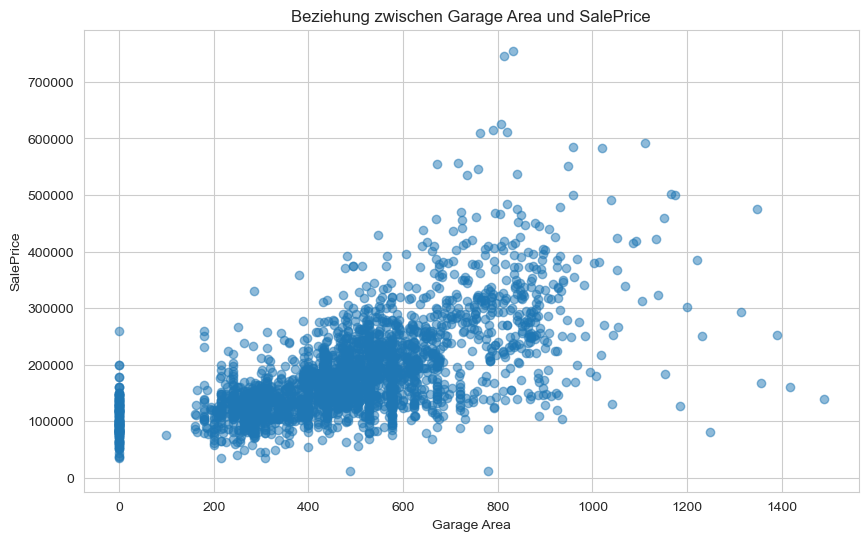

In [33]:
# Scatter Plot: Garage Area und SalePrice
plt.figure(figsize=(10, 6))
plt.scatter(df['Garage Area'], df['SalePrice'], alpha=0.5)
plt.title('Beziehung zwischen Garage Area und SalePrice')
plt.xlabel('Garage Area')
plt.ylabel('SalePrice')
plt.show()

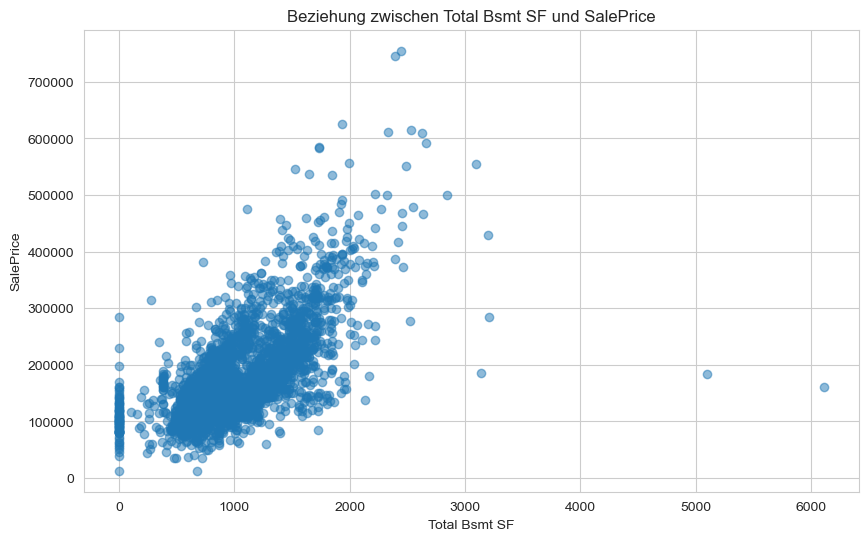

In [34]:
# Scatter Plot: Total Bsmt SF und SalePrice
plt.figure(figsize=(10, 6))
plt.scatter(df['Total Bsmt SF'], df['SalePrice'], alpha=0.5)
plt.title('Beziehung zwischen Total Bsmt SF und SalePrice')
plt.xlabel('Total Bsmt SF')
plt.ylabel('SalePrice')
plt.show()

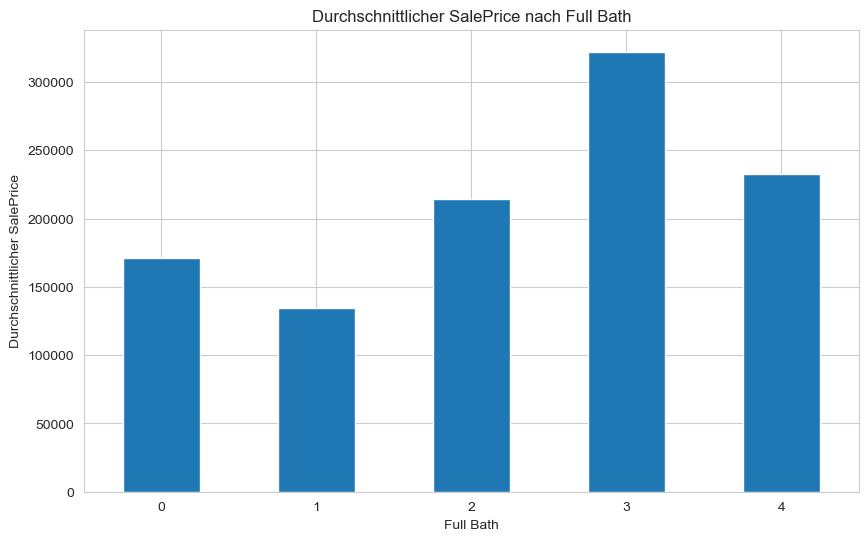

In [35]:
# Durchschnittlicher SalePrice nach Full Bath
avg_price_bath = df.groupby('Full Bath')['SalePrice'].mean()

plt.figure(figsize=(10, 6))
avg_price_bath.plot(kind='bar')
plt.title('Durchschnittlicher SalePrice nach Full Bath')
plt.xlabel('Full Bath')
plt.ylabel('Durchschnittlicher SalePrice')
plt.xticks(rotation=0)
plt.show()

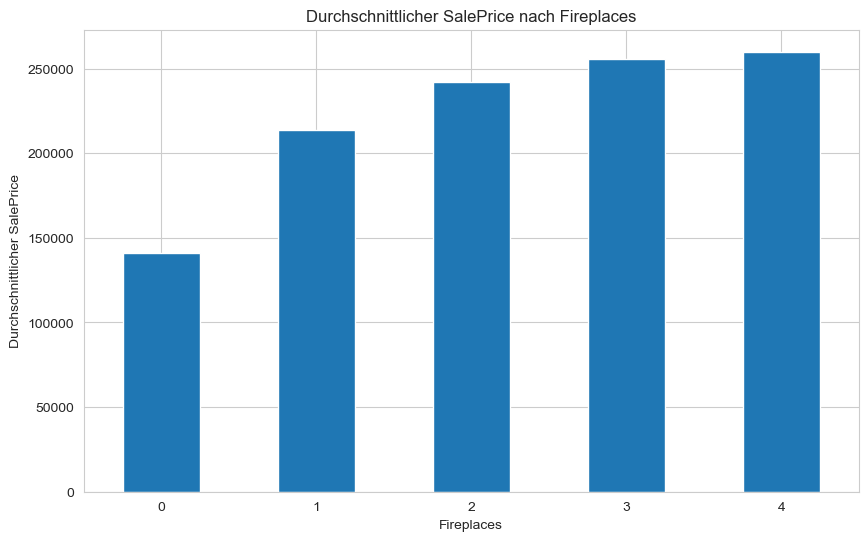

In [36]:
# Durchschnittlicher SalePrice nach Fireplaces
avg_price_fireplaces = df.groupby('Fireplaces')['SalePrice'].mean()

plt.figure(figsize=(10, 6))
avg_price_fireplaces.plot(kind='bar')
plt.title('Durchschnittlicher SalePrice nach Fireplaces')
plt.xlabel('Fireplaces')
plt.ylabel('Durchschnittlicher SalePrice')
plt.xticks(rotation=0)
plt.show()